In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import osmnx as ox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.path import Path
import matplotlib.patches as mpatches
from matplotlib.transforms import Affine2D



Map saved to: output/plots/report/christchurch_city_boundary.png
City boundary area: 0.03 square degrees


/var/folders/mw/92tzvh5x7098x2prk2dnt57w0000gn/T/ipykernel_66621/3976943610.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"City boundary area: {city.geometry.area.values[0]:.2f} square degrees")


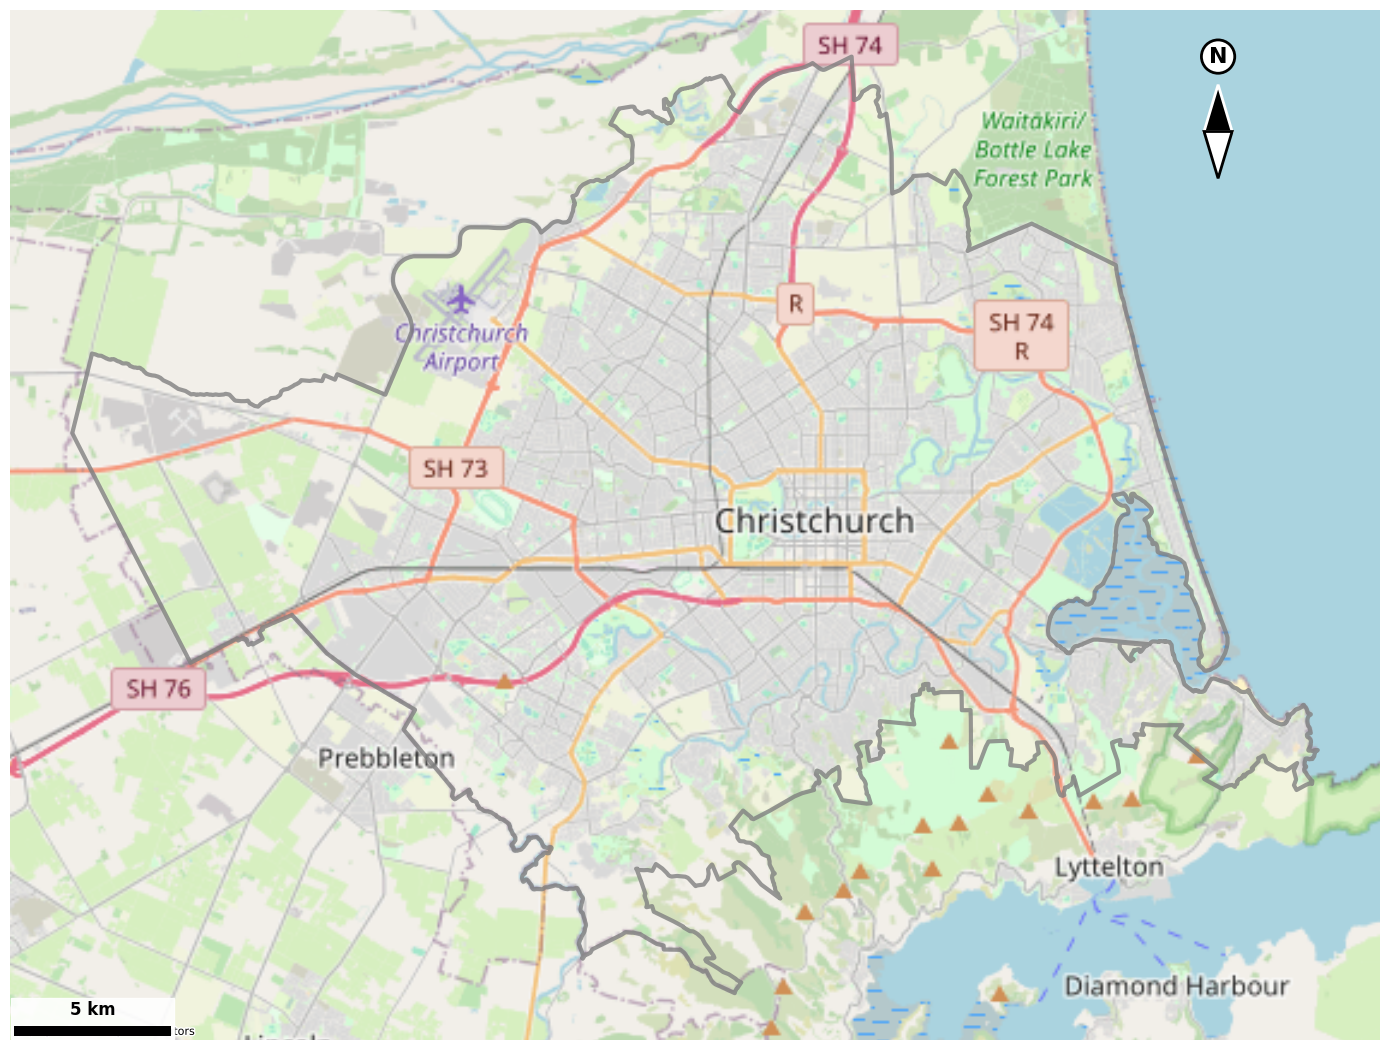

'\nprint("Loading Christchurch boundary from local file...")\ncity_boundary = gpd.read_file(\'path_to_christchurch_boundary.shp\')\ncity_boundary = city_boundary.to_crs(epsg=3857)  # Convert to Web Mercator\n\nfig, ax = plt.subplots(figsize=(14, 16))\ncity_boundary.plot(ax=ax, facecolor=\'none\', edgecolor=\'red\', linewidth=3)\nctx.add_basemap(ax, crs=city_boundary.crs, source=ctx.providers.CartoDB.Voyager)\nax.set_title(\'Christchurch City Boundary\', fontsize=18, fontweight=\'bold\')\nax.set_axis_off()\nplt.tight_layout()\nplt.savefig(\'outputs/plots/report/christchurch_city_boundary.png\', dpi=300)\n'

In [3]:
city = ox.geocode_to_gdf('Christchurch, New Zealand')

city_web = city.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 16))

city_web.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=3, alpha=0.8)

ctx.add_basemap(ax, crs=city_web.crs, source=ctx.providers.OpenStreetMap.Mapnik)  # Standard OSM

# Add title and labels
ax.grid(False)
ax.set_axis_off()  # Turn off axes for cleaner look

# Get bounds for positioning north arrow and scale bar
bounds = city_web.total_bounds  # minx, miny, maxx, maxy
x_range = bounds[2] - bounds[0]
y_range = bounds[3] - bounds[1]

# Add professional north arrow (compass style)
arrow_x = bounds[2] - x_range * 0.08
arrow_y = bounds[3] - y_range * 0.08
arrow_size = y_range * 0.05

# Main arrow pointing north (filled triangle)
arrow_points = [
    [arrow_x, arrow_y + arrow_size],  # top
    [arrow_x - arrow_size * 0.3, arrow_y],  # bottom left
    [arrow_x + arrow_size * 0.3, arrow_y]   # bottom right
]

from matplotlib.patches import Polygon
north_arrow = Polygon(arrow_points, closed=True, facecolor='black', edgecolor='white', linewidth=2)
ax.add_patch(north_arrow)

# Add south pointer (unfilled)
south_points = [
    [arrow_x, arrow_y - arrow_size],  # bottom
    [arrow_x - arrow_size * 0.3, arrow_y],  # top left
    [arrow_x + arrow_size * 0.3, arrow_y]   # top right
]
south_arrow = Polygon(south_points, closed=True, facecolor='white', edgecolor='black', linewidth=2)
ax.add_patch(south_arrow)

# Add 'N' label
ax.text(arrow_x, arrow_y + arrow_size * 1.6, 'N', 
        ha='center', va='center',
        fontsize=16, fontweight='bold',
        color='black',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', linewidth=2))

# Add scale bar (10 km)
from matplotlib_scalebar.scalebar import ScaleBar
scalebar = ScaleBar(1, units='m', location='lower left', 
                   length_fraction=0.2,
                   font_properties={'size': 12, 'weight': 'bold'},
                   box_alpha=0.9, color='black', box_color='white',
                   scale_loc='top')
ax.add_artist(scalebar)

plt.tight_layout()

# Save
output_path = 'output/plots/report/christchurch_city_boundary.png'
# plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nMap saved to: {output_path}")
print(f"City boundary area: {city.geometry.area.values[0]:.2f} square degrees")

plt.show()


# Alternative Method 2: If you have a shapefile/GeoPackage with city boundaries
# Uncomment below if you have a local boundary file:

"""
print("Loading Christchurch boundary from local file...")
city_boundary = gpd.read_file('path_to_christchurch_boundary.shp')
city_boundary = city_boundary.to_crs(epsg=3857)  # Convert to Web Mercator

fig, ax = plt.subplots(figsize=(14, 16))
city_boundary.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=3)
ctx.add_basemap(ax, crs=city_boundary.crs, source=ctx.providers.CartoDB.Voyager)
ax.set_title('Christchurch City Boundary', fontsize=18, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('outputs/plots/report/christchurch_city_boundary.png', dpi=300)
"""

In [4]:
canopy = gpd.read_file('data/canopy.gdb')
gdf = gpd.read_file("output/property_ring.gpkg")

/Users/rujalshrestha/Projects/chc-property-prices/venv/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Loading property data...
  Loaded 12,317 properties

  Selected property at index 6277
  Coordinates: (1570435.81, 5175313.02)

Creating buffer rings...

Loading canopy data within 500m...
  Loaded 1,909 canopy polygons within 500m

Splitting canopy polygons by rings...
  0-20: 6 polygon pieces
  20-50: 18 polygon pieces
  50-100: 67 polygon pieces
  100-200: 212 polygon pieces
  200-500: 1274 polygon pieces

Converting to Web Mercator...

Creating visualization...

  Saved: canopy_buffer_conceptual_high_contrast.png


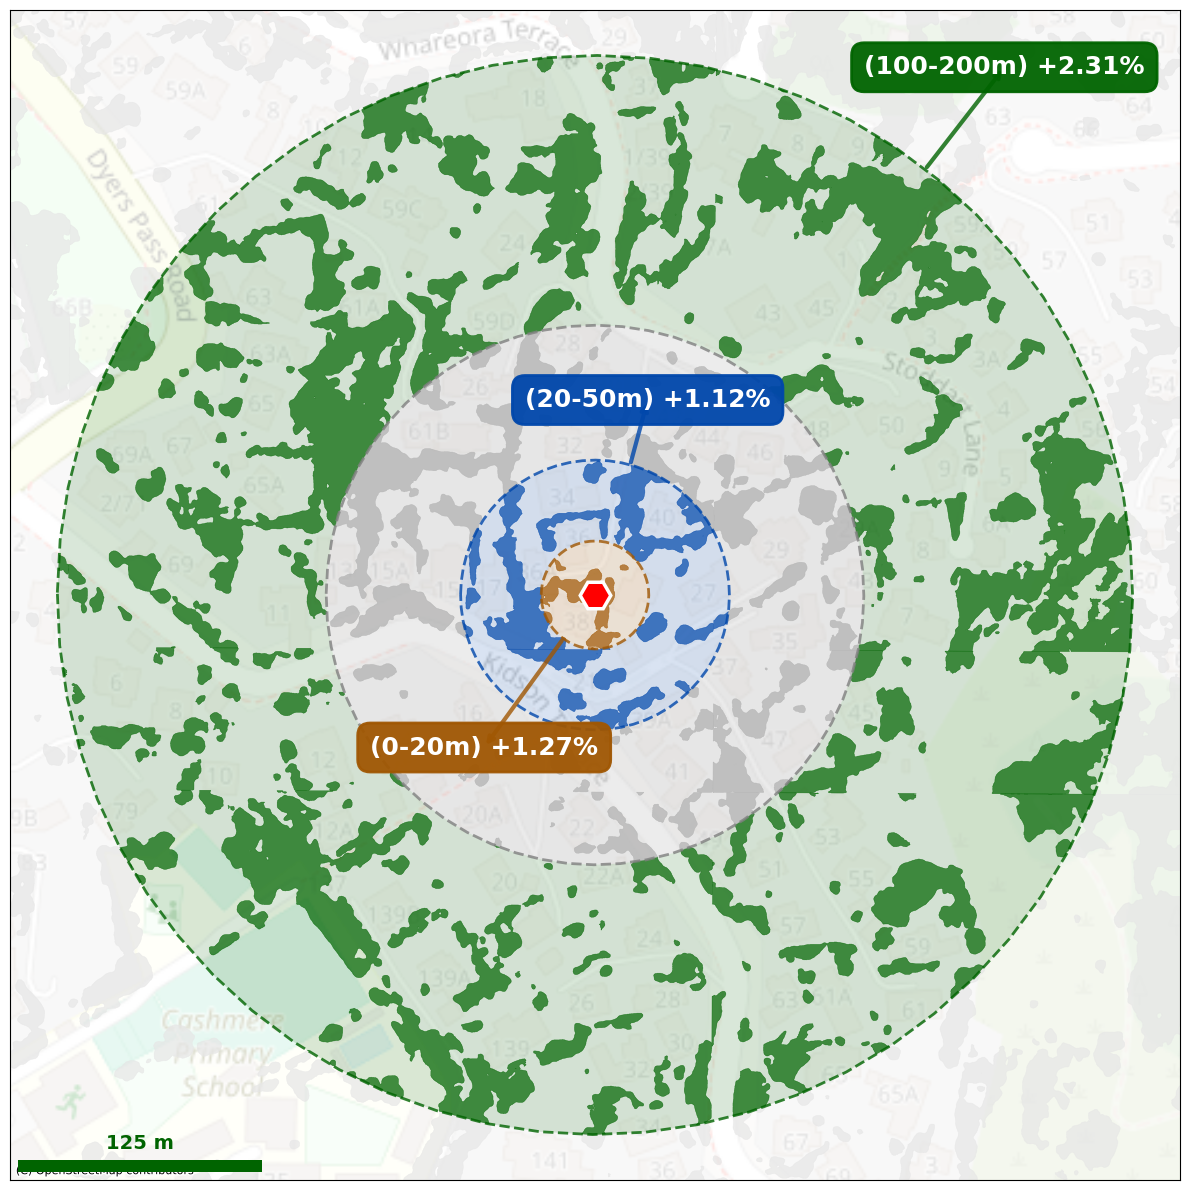

In [81]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import contextily as ctx
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load property data
print("Loading property data...")
property_gdf = gpd.read_file('output/property_all.gpkg')
print(f"  Loaded {len(property_gdf):,} properties")

# Select one property (you can change the index)

# property_idx = 4783  # Change this to select different property
# property_idx = 4788  # Change this to select different property
# property_idx = 4792  # Change this to select different property
property_idx = 6277  # Change this to select different property
selected_property = property_gdf.iloc[property_idx]
property_point = selected_property.geometry
print(f"\n  Selected property at index {property_idx}")
print(f"  Coordinates: ({property_point.x:.2f}, {property_point.y:.2f})")

# Create buffer rings as geometries IN ORIGINAL CRS
print("\nCreating buffer rings...")
buffer_distances = [20, 50, 100, 200, 500]
buffers = {dist: property_point.buffer(dist) for dist in buffer_distances}

# Create ring geometries (donut shapes) - ORDER MATTERS (innermost to outermost)
rings_ordered = [
    ('0-20', buffers[20]),
    ('20-50', buffers[50].difference(buffers[20])),
    ('50-100', buffers[100].difference(buffers[50])),
    ('100-200', buffers[200].difference(buffers[100])),
    ('200-500', buffers[500].difference(buffers[200]))
]

# Load canopy only within 500m (to keep it light)
print("\nLoading canopy data within 500m...")
canopy = gpd.read_file('data/canopy.gdb', bbox=buffers[500].bounds)
print(f"  Loaded {len(canopy):,} canopy polygons within 500m")

# Split each canopy polygon by rings and assign colors
print("\nSplitting canopy polygons by rings...")
canopy_by_ring = {name: [] for name, _ in rings_ordered}

for idx, canopy_poly in canopy.iterrows():
    geom = canopy_poly.geometry
    
    # Check each ring from innermost to outermost
    for ring_name, ring_geom in rings_ordered:
        if geom.intersects(ring_geom):
            # Get the part of canopy in this ring
            clipped = geom.intersection(ring_geom)
            if not clipped.is_empty:
                canopy_by_ring[ring_name].append(clipped)

# Convert to GeoDataFrames
canopy_rings = {}
for ring_name, geoms in canopy_by_ring.items():
    if len(geoms) > 0:
        canopy_rings[ring_name] = gpd.GeoDataFrame(geometry=geoms, crs=property_gdf.crs)
        print(f"  {ring_name}: {len(geoms)} polygon pieces")

# Convert rings to Web Mercator
print("\nConverting to Web Mercator...")
rings_web = {}
for ring_name, ring_geom in rings_ordered:
    ring_gdf = gpd.GeoDataFrame(geometry=[ring_geom], crs=property_gdf.crs)
    rings_web[ring_name] = ring_gdf.to_crs(epsg=3857).geometry.iloc[0]

# Convert property to Web Mercator
property_web = gpd.GeoDataFrame(
    [selected_property], 
    geometry=[property_point], 
    crs=property_gdf.crs
).to_crs(epsg=3857)

# Convert canopy to Web Mercator
canopy_rings_web = {}
for ring_name, canopy_gdf in canopy_rings.items():
    canopy_rings_web[ring_name] = canopy_gdf.to_crs(epsg=3857)

# Create the plot
print("\nCreating visualization...")
fig, ax = plt.subplots(figsize=(12, 12))

# Plot canopy in different colors for each ring - HIGH CONTRAST COLORS
colors = {
    '0-20': "#A05703",      # Dark red (high contrast)
    '20-50': '#0047AB',     # Cobalt blue (high contrast)
    '50-100': "#B9B9B9",    # Grey (insignificant)
    '100-200': '#006400',   # Dark green (high contrast)
    '200-500': "#E6E6E6"    # Grey
}

# Plot from outer to inner
for ring_name in ['200-500', '100-200', '50-100', '20-50', '0-20']:
    if ring_name in canopy_rings_web and len(canopy_rings_web[ring_name]) > 0:
        canopy_rings_web[ring_name].plot(ax=ax, color=colors[ring_name], alpha=0.7, 
                                         edgecolor=colors[ring_name], linewidth=0.3)

# Get property point in Web Mercator
property_point_web = property_web.geometry.iloc[0]

# Plot buffer rings as dashed circles - use the actual ring boundaries
ring_colors = {
    '0-20': '#A05703',   # Dark red
    '20-50': '#0047AB',   # Cobalt blue
    '50-100': '#808080',  # Grey
    '100-200': '#006400'   # Dark green
}

# Plot the ring boundaries
for ring_name, color in ring_colors.items():
    ring_geom = rings_web[ring_name]
    
    # Add light background fill
    ring_gdf_fill = gpd.GeoDataFrame(geometry=[ring_geom], crs='EPSG:3857')
    ring_gdf_fill.plot(ax=ax, color=color, alpha=0.15, edgecolor='none')
    
    # Get the outer boundary of each ring
    if ring_name == '0-20':
        # For first ring, plot the outer boundary
        boundary_gdf = gpd.GeoDataFrame(geometry=[ring_geom.boundary], crs='EPSG:3857')
        boundary_gdf.plot(ax=ax, color=color, linestyle='--', linewidth=2, alpha=0.8)
    else:
        # For donut rings, plot the outer boundary only
        if hasattr(ring_geom.boundary, 'geoms'):
            # MultiLineString - get the outer boundary (largest)
            boundaries = list(ring_geom.boundary.geoms)
            outer = max(boundaries, key=lambda x: x.length)
            boundary_gdf = gpd.GeoDataFrame(geometry=[outer], crs='EPSG:3857')
            boundary_gdf.plot(ax=ax, color=color, linestyle='--', linewidth=2, alpha=0.8)

# Add effect labels with arrows
effects = {
    '0-20': ('+1.27%', '#A05703'),
    '20-50': ('+1.12%', '#0047AB'),
    '100-200': ('+2.31%', '#006400')
}

# Label positions (angle in radians, distance multiplier)
label_configs = {
    '0-20': (np.pi * 1.30, 3.5),      # 270 degrees (bottom)
    '20-50': (np.pi *0.416, 1.5),          # 180 degrees (left)
    '100-200': (np.pi * 0.29, 1.24)       # 30 degrees (top right)
    # '100-200': (np.pi * 0.5, 0.8)       # 30 degrees (top right)
}

for ring_name, (angle, dist_mult) in label_configs.items():
    effect_text, color = effects[ring_name]
    
    # Get the outer boundary of the ring
    ring_geom = rings_web[ring_name]
    if ring_name == '0-20':
        boundary = ring_geom.boundary
    else:
        if hasattr(ring_geom.boundary, 'geoms'):
            boundaries = list(ring_geom.boundary.geoms)
            boundary = max(boundaries, key=lambda x: x.length)
        else:
            boundary = ring_geom.boundary
    
    # Get a point on the boundary at the specified angle
    coords = list(boundary.coords)
    # Find the approximate radius (distance from center)
    distances = [np.sqrt((x - property_point_web.x)**2 + (y - property_point_web.y)**2) 
                 for x, y in coords]
    avg_radius = np.mean(distances)
    
    # Ring edge point (where arrow starts)
    ring_x = property_point_web.x + avg_radius * np.cos(angle)
    ring_y = property_point_web.y + avg_radius * np.sin(angle)
    
    # Label position (where arrow ends)
    label_x = property_point_web.x + avg_radius * dist_mult * np.cos(angle)
    label_y = property_point_web.y + avg_radius * dist_mult * np.sin(angle)
    
    # Add text with background
    if ring_name == '0-20':
        ring_label = '(0-20m)'
    elif ring_name == '20-50':
        ring_label = '(20-50m)'
    else:
        ring_label = '(100-200m)'
    
    bbox_props = dict(boxstyle='round,pad=0.5', facecolor=color, 
                     edgecolor=color, linewidth=2, alpha=0.95)
    ax.text(label_x, label_y, f'{ring_label} {effect_text}',
           fontsize=18, fontweight='bold', color='white',
           bbox=bbox_props, ha='center', va='center', zorder=20)
    
    # Add arrow from ring edge to label
    # if ring_name != '100-200':
    ax.annotate('', xy=(label_x, label_y), xytext=(ring_x, ring_y),
            arrowprops=dict(arrowstyle='->', color=color, 
                            lw=3, alpha=0.8), zorder=19)

ax.plot(property_point_web.x, property_point_web.y, marker='H', color='red', markersize=22, 
       markeredgecolor='white', markeredgewidth=2.5, zorder=25)

# Add color basemap with higher zoom for sharper detail
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.2, zoom=17)

# Set equal aspect ratio and limits
ax.set_aspect('equal')
margin = 300
ax.set_xlim(property_point_web.x - margin, property_point_web.x + margin)
ax.set_ylim(property_point_web.y - margin, property_point_web.y + margin)

# Remove axis labels and ticks for cleaner look
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

# # Add north arrow
# from matplotlib.patches import Polygon
# bounds = ax.get_xlim(), ax.get_ylim()
# x_range = bounds[0][1] - bounds[0][0]
# y_range = bounds[1][1] - bounds[1][0]

# arrow_x = bounds[0][1] - x_range * 0.12
# arrow_y = bounds[1][1] - y_range * 0.12
# arrow_size = y_range * 0.05

# # Main arrow pointing north
# arrow_points = [
#     [arrow_x, arrow_y + arrow_size],
#     [arrow_x - arrow_size * 0.3, arrow_y],
#     [arrow_x + arrow_size * 0.3, arrow_y]
# ]
# north_arrow = Polygon(arrow_points, closed=True, facecolor='black', edgecolor='white', linewidth=2, zorder=30)
# ax.add_patch(north_arrow)

# # South pointer
# south_points = [
#     [arrow_x, arrow_y - arrow_size],
#     [arrow_x - arrow_size * 0.3, arrow_y],
#     [arrow_x + arrow_size * 0.3, arrow_y]
# ]
# south_arrow = Polygon(south_points, closed=True, facecolor='white', edgecolor='black', linewidth=2, zorder=30)
# ax.add_patch(south_arrow)

# # 'N' label
# ax.text(arrow_x, arrow_y + arrow_size * 1.6, 'N', 
#         ha='center', va='center',
#         fontsize=14, fontweight='bold',
#         color='black',
#         bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', linewidth=2),
#         zorder=30)

# Add scale bar
from matplotlib_scalebar.scalebar import ScaleBar
scalebar = ScaleBar(1, units='m', location='lower left', 
                   length_fraction=0.25,
                   font_properties={'size': 14, 'weight': 'bold'},
                   box_alpha=0.95, color='darkgreen', box_color='none',
                   scale_loc='top', pad=0.5)
ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig('output/plots/report/canopy_rings_poster.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n  Saved: canopy_buffer_conceptual_high_contrast.png")
plt.show()

In [5]:
import geopandas as gpd
import folium
from folium import plugins
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

# Load property data
print("Loading property data...")
property_gdf = gpd.read_file('output/property_all.gpkg')
print(f"  Loaded {len(property_gdf):,} properties")

# Load canopy data
print("\nLoading canopy data...")
canopy = gpd.read_file('data/canopy.gdb')
canopy_wgs84 = canopy.to_crs(epsg=4326)
print(f"  Loaded {len(canopy):,} canopy polygons")

# Convert to WGS84 (lat/lon) for folium
property_gdf_wgs84 = property_gdf.to_crs(epsg=4326)

Loading property data...
  Loaded 12,317 properties

Loading canopy data...
  Loaded 335,944 canopy polygons


In [6]:
sa2 = gpd.read_file('data/chc-boundaries/sa2/statistical-area-2-2023-generalised.shp')
ta  = gpd.read_file('data/chc-boundaries/territorial-authority-2021-generalised.gpkg')

In [7]:
SA2_PATH = 'data/chc-boundaries/sa2/statistical-area-2-2023-generalised.shp'
CANOPY_PATH = 'data/canopy.gdb'
 
 # Get Christchurch city boundary from OSMnx
print("Getting Christchurch city boundary from OSMnx...")
city = ox.geocode_to_gdf('Christchurch, New Zealand')
city = city.to_crs(epsg=2193)  # Convert to NZTM

print(f"City boundary loaded: {city.display_name.values[0]}")

# Load the data
print("\nLoading SA2 and canopy data...")
sa2 = gpd.read_file(SA2_PATH)
canopy = gpd.read_file(CANOPY_PATH)

# Ensure everything is in NZTM (EPSG:2193)

if sa2.crs != 'EPSG:2193':
    sa2 = sa2.to_crs(epsg=2193)
if canopy.crs != 'EPSG:2193':
    canopy = canopy.to_crs(epsg=2193)
    
# Clip SA2 to city boundary
print("\nClipping SA2 to Christchurch city boundary...")
sa2_clipped = gpd.overlay(sa2, city, how='intersection')
print(f"SA2 areas within city boundary: {len(sa2_clipped)}")

# Clip canopy to city boundary
print("Clipping canopy to city boundary...")
canopy_clipped = gpd.overlay(canopy, city, how='intersection')
print(f"Canopy polygons within city: {len(canopy_clipped)}")

# Intersect canopy with SA2 boundaries
canopy_by_sa2 = gpd.overlay(canopy_clipped, sa2_clipped, how='intersection', keep_geom_type=False)

# Calculate area of canopy within each SA2
canopy_by_sa2['canopy_area_m2'] = canopy_by_sa2.geometry.area

# Group by SA2 and sum canopy area
sa2_id_col = 'SA22023_V1' if 'SA22023_V1' in canopy_by_sa2.columns else canopy_by_sa2.columns[0]
canopy_summary = canopy_by_sa2.groupby(sa2_id_col)['canopy_area_m2'].sum().reset_index()
canopy_summary.columns = [sa2_id_col, 'total_canopy_area_m2']

# Merge with SA2 to get total SA2 area
sa2_with_canopy = sa2_clipped.merge(canopy_summary, on=sa2_id_col, how='left')
sa2_with_canopy['total_canopy_area_m2'] = sa2_with_canopy['total_canopy_area_m2'].fillna(0)

# Calculate SA2 area in m²
sa2_with_canopy['sa2_area_m2'] = sa2_with_canopy.geometry.area

# Calculate canopy percentage
sa2_with_canopy['canopy_percentage'] = (
    sa2_with_canopy['total_canopy_area_m2'] / 
    sa2_with_canopy['sa2_area_m2'] * 100
)

# Convert to Web Mercator for plotting with basemap
print("\nConverting to Web Mercator for visualization...")
sa2_web = sa2_with_canopy.to_crs(epsg=3857)
city_web = city.to_crs(epsg=3857)

Getting Christchurch city boundary from OSMnx...
City boundary loaded: Christchurch, Christchurch City, Canterbury, New Zealand

Loading SA2 and canopy data...

Clipping SA2 to Christchurch city boundary...
SA2 areas within city boundary: 174
Clipping canopy to city boundary...
Canopy polygons within city: 296063

Converting to Web Mercator for visualization...


Creating chloropleth map...


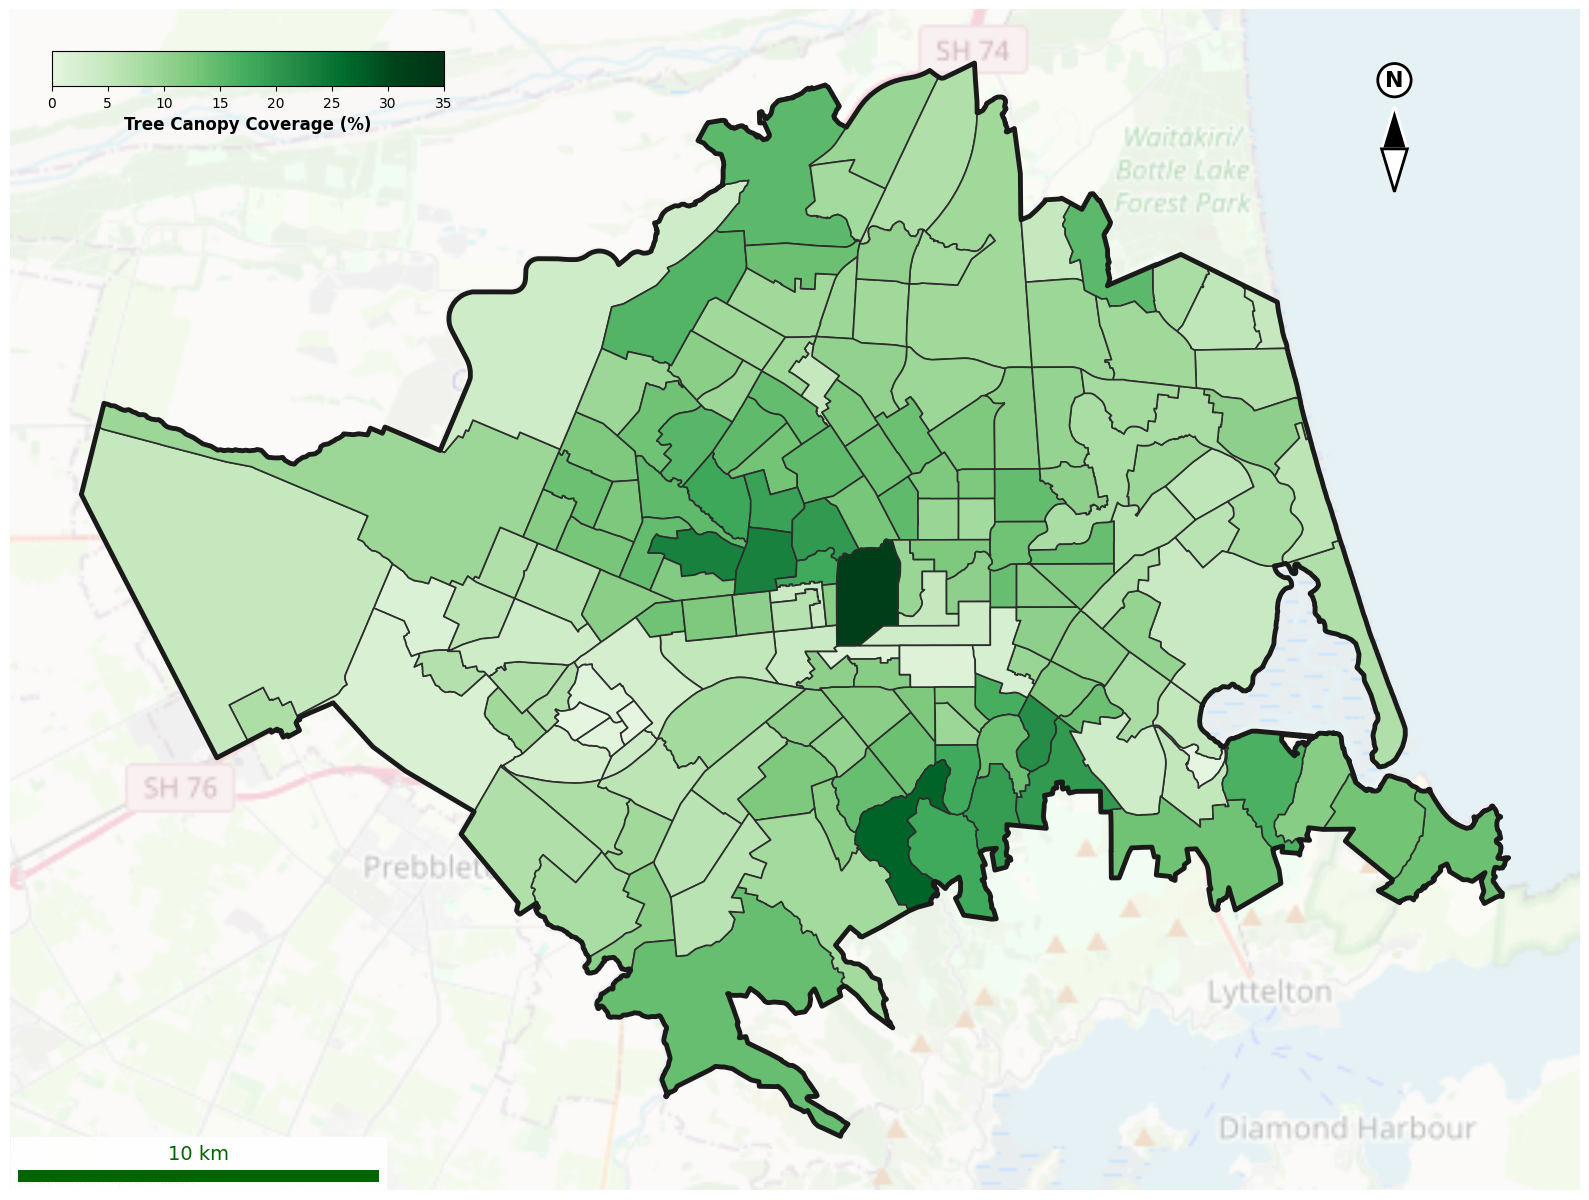

In [9]:
"""
Tree Canopy Coverage Chloropleth Map - Christchurch City Boundary (OSMnx)
Author: Rujal Shrestha
Date: January 2026

This script creates a chloropleth map showing tree canopy coverage 
by SA2, clipped to the exact Christchurch city boundary from OSMnx.
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import osmnx as ox
from matplotlib.colors import LinearSegmentedColormap
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Polygon
import numpy as np
import os

def create_canopy_chloropleth_city_boundary(output_path='canopy_coverage_christchurch.png'):
    print("Creating chloropleth map...")
    fig, ax = plt.subplots(figsize=(16, 18))
    
    # Create custom colormap (darker greens - earth tones)
    colors = [
        '#e5f5e0',  # Light green (darker starting point)
        '#c7e9c0',  # Pale green
        '#a1d99b',  # Light sage
        '#74c476',  # Medium green
        '#41ab5d',  # Forest green
        '#238b45',  # Dark green
        '#006d2c',  # Deep forest
        '#00441b',  # Very dark green
        '#003314'   # Almost black green
    ]
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('canopy', colors, N=n_bins)
    
    # Plot SA2 with canopy percentage
    
    # Plot without legend first (with darker boundaries)
    sa2_web.plot(column='canopy_percentage', 
                ax=ax, 
                cmap=cmap,
                edgecolor='#2d2d2d',  # Much darker gray (almost black)
                linewidth=1.2,  # Thicker lines
                legend=False,  # Turn off automatic legend
                vmin=0,
                vmax=max(35, sa2_with_canopy['canopy_percentage'].quantile(0.95)),
                missing_kwds={'color': 'lightgray', 'edgecolor': '#2d2d2d', 'label': 'No Data'})


    # Create inset axes for colorbar (bottom right corner)
    cax = inset_axes(ax, 
                    width="25%",  # Width of colorbar
                    height="3%",   # Height of colorbar
                    loc='upper left',  # Position
                    bbox_to_anchor=(0, 0, 1, 1),  # (x, y, width, height) in axes coordinates
                    bbox_transform=ax.transAxes,
                    borderpad=3)  # Padding from edge

    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, 
                            norm=plt.Normalize(vmin=0, 
                                                vmax=max(35, sa2_with_canopy['canopy_percentage'].quantile(0.95))))
    sm._A = []
    cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Tree Canopy Coverage (%)', size=12, weight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Plot city boundary on top (darker)
    city_web.plot(ax=ax, facecolor='none', edgecolor='#1a1a1a', linewidth=3.5, alpha=1.0)
    
    # Add basemap
    try:
        ctx.add_basemap(ax, crs=sa2_web.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.3)
    except:
        print("Warning: Could not add basemap. Continuing without basemap...")
    
    # Title
    # ax.set_title('Tree Canopy Coverage by Statistical Area 2\nChristchurch, New Zealand', 
    #              fontsize=24, fontweight='bold', pad=20, color='#2d5f3f')
    
    # Turn off axes
    ax.set_axis_off()
    
    # Add north arrow
    bounds = sa2_web.total_bounds
    x_range = bounds[2] - bounds[0]
    y_range = bounds[3] - bounds[1]
    
    arrow_x = bounds[2] - x_range * 0.08
    arrow_y = bounds[3] - y_range * 0.08
    arrow_size = y_range * 0.04
    
    # Main arrow pointing north
    arrow_points = [
        [arrow_x, arrow_y + arrow_size],
        [arrow_x - arrow_size * 0.3, arrow_y],
        [arrow_x + arrow_size * 0.3, arrow_y]
    ]
    north_arrow = Polygon(arrow_points, closed=True, facecolor='black', edgecolor='white', linewidth=2)
    ax.add_patch(north_arrow)
    
    # South pointer
    south_points = [
        [arrow_x, arrow_y - arrow_size],
        [arrow_x - arrow_size * 0.3, arrow_y],
        [arrow_x + arrow_size * 0.3, arrow_y]
    ]
    south_arrow = Polygon(south_points, closed=True, facecolor='white', edgecolor='black', linewidth=2)
    ax.add_patch(south_arrow)
    
    # 'N' label
    ax.text(arrow_x, arrow_y + arrow_size * 1.6, 'N', 
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            color='black',
            bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', linewidth=2))
    
    # Add scale bar
    scalebar = ScaleBar(1, units='m', location='lower left', 
                       length_fraction=0.25,
                       font_properties={'size': 14},
                       box_alpha=0.95, color='darkgreen', box_color='white',
                       scale_loc='top', pad=0.5)
    
    ax.add_artist(scalebar)
    
    
    plt.tight_layout()
    
    # Save
    # plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            
    plt.show()
    
    return sa2_with_canopy


# Example usage:
if __name__ == "__main__":
    # Adjust these paths to match your data structure
    OUTPUT_PATH = 'output/plots/report/PRESENTATION_canopy_chc.png'
        
    result = create_canopy_chloropleth_city_boundary(OUTPUT_PATH)

In [ ]:
"""
Tree Canopy Coverage Chloropleth Map - WHITE TO DARKEST GREEN
Author: Rujal Shrestha
Date: January 2026

Simple, high-contrast gradient: White (no canopy) → Darkest Green (max canopy)
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import osmnx as ox
from matplotlib.colors import LinearSegmentedColormap
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Polygon
import numpy as np
import os

def create_canopy_chloropleth_white_to_green(sa2_path, canopy_path, output_path='canopy_coverage_white_to_green.png'):
    """
    Create a chloropleth map with white to darkest green.
    
    Parameters:
    -----------
    sa2_path : str
        Path to SA2 boundary shapefile/geopackage
    canopy_path : str
        Path to tree canopy data (shapefile/geopackage)
    output_path : str
        Output path for the map image
    """
    
    # Get Christchurch city boundary from OSMnx
    print("Getting Christchurch city boundary from OSMnx...")
    city = ox.geocode_to_gdf('Christchurch, New Zealand')
    city = city.to_crs(epsg=2193)
    
    # Load the data
    print("\nLoading SA2 and canopy data...")
    sa2 = gpd.read_file(sa2_path)
    canopy = gpd.read_file(canopy_path)
    
    print(f"SA2 records: {len(sa2)}")
    print(f"Canopy polygons: {len(canopy)}")
    
    # Ensure everything is in NZTM
    print("\nReprojecting to NZTM (EPSG:2193)...")
    if sa2.crs != 'EPSG:2193':
        sa2 = sa2.to_crs(epsg=2193)
    if canopy.crs != 'EPSG:2193':
        canopy = canopy.to_crs(epsg=2193)
    
    # Clip to city boundary
    print("\nClipping to Christchurch city boundary...")
    sa2_clipped = gpd.overlay(sa2, city, how='intersection')
    canopy_clipped = gpd.overlay(canopy, city, how='intersection')
    
    print(f"SA2 areas within city: {len(sa2_clipped)}")
    print(f"Canopy polygons within city: {len(canopy_clipped)}")
    
    # Calculate canopy coverage per SA2
    print("\nCalculating canopy coverage by SA2...")
    canopy_by_sa2 = gpd.overlay(canopy_clipped, sa2_clipped, how='intersection', keep_geom_type=False)
    canopy_by_sa2['canopy_area_m2'] = canopy_by_sa2.geometry.area
    
    sa2_id_col = 'SA22023_V1' if 'SA22023_V1' in canopy_by_sa2.columns else canopy_by_sa2.columns[0]
    canopy_summary = canopy_by_sa2.groupby(sa2_id_col)['canopy_area_m2'].sum().reset_index()
    canopy_summary.columns = [sa2_id_col, 'total_canopy_area_m2']
    
    sa2_with_canopy = sa2_clipped.merge(canopy_summary, on=sa2_id_col, how='left')
    sa2_with_canopy['total_canopy_area_m2'] = sa2_with_canopy['total_canopy_area_m2'].fillna(0)
    sa2_with_canopy['sa2_area_m2'] = sa2_with_canopy.geometry.area
    sa2_with_canopy['canopy_percentage'] = (
        sa2_with_canopy['total_canopy_area_m2'] / 
        sa2_with_canopy['sa2_area_m2'] * 100
    )
    
    # Convert to Web Mercator
    print("\nConverting to Web Mercator...")
    sa2_web = sa2_with_canopy.to_crs(epsg=3857)
    city_web = city.to_crs(epsg=3857)
    
    # Create the plot
    print("Creating white-to-green chloropleth map...")
    fig, ax = plt.subplots(figsize=(16, 18))
    
    # WHITE TO DARKEST GREEN - Simple, high contrast
    colors_white_to_darkest_green = [
        '#ffffff',  # Pure white (0% canopy)
        '#f0f9f0',  # Very very pale green
        '#d9f2d9',  # Very pale green
        '#bde5bd',  # Pale green
        '#9dd89d',  # Light green
        '#7ccb7c',  # Light-medium green
        '#5abe5a',  # Medium green
        '#3da13d',  # Medium-dark green
        '#2d842d',  # Dark green
        '#1d671d',  # Darker green
        '#0d4a0d',  # Very dark green
        '#002d00'   # Darkest possible green (almost black)
    ]
    
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('white_to_darkest_green', colors_white_to_darkest_green, N=n_bins)
    
    # Plot with high contrast settings
    sa2_web.plot(column='canopy_percentage', 
                 ax=ax, 
                 cmap=cmap,
                 edgecolor='#3d3d3d',  # Dark gray edges
                 linewidth=0.9,
                 legend=True,
                 vmin=0,
                 vmax=sa2_with_canopy['canopy_percentage'].quantile(0.98),
                 legend_kwds={
                    'label': 'Tree Canopy Coverage (%)',
                    'orientation': 'horizontal',
                    'shrink': 0.5,
                    'aspect': 15,
                    'pad': 0.05,
                    'anchor': (1.0, 0.0),  # Bottom right corner
                    'panchor': (1.0, 0.0)
                },
                missing_kwds={'color': '#ffffff', 'edgecolor': '#3d3d3d', 'label': 'No Data'})
    
    # City boundary
    city_web.plot(ax=ax, facecolor='none', edgecolor='#2d2d2d', linewidth=3.5, alpha=0.9)
    
    # Light basemap
    try:
        ctx.add_basemap(ax, crs=sa2_web.crs, source=ctx.providers.CartoDB.Positron, alpha=0.25)
    except:
        print("Warning: Could not add basemap.")
    
    # Title
    ax.set_title('Tree Canopy Coverage by Statistical Area 2 (SA2)\nChristchurch, New Zealand', 
                 fontsize=24, fontweight='bold', pad=20, color='#2d5f3f')
    
    ax.set_axis_off()
    
    # North arrow
    bounds = sa2_web.total_bounds
    x_range = bounds[2] - bounds[0]
    y_range = bounds[3] - bounds[1]
    
    arrow_x = bounds[2] - x_range * 0.08
    arrow_y = bounds[3] - y_range * 0.08
    arrow_size = y_range * 0.04
    
    arrow_points = [
        [arrow_x, arrow_y + arrow_size],
        [arrow_x - arrow_size * 0.3, arrow_y],
        [arrow_x + arrow_size * 0.3, arrow_y]
    ]
    north_arrow = Polygon(arrow_points, closed=True, facecolor='black', edgecolor='white', linewidth=2)
    ax.add_patch(north_arrow)
    
    south_points = [
        [arrow_x, arrow_y - arrow_size],
        [arrow_x - arrow_size * 0.3, arrow_y],
        [arrow_x + arrow_size * 0.3, arrow_y]
    ]
    south_arrow = Polygon(south_points, closed=True, facecolor='white', edgecolor='black', linewidth=2)
    ax.add_patch(south_arrow)
    
    ax.text(arrow_x, arrow_y + arrow_size * 1.6, 'N', 
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            color='black',
            bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', linewidth=2))
    
    # Scale bar
    scalebar = ScaleBar(1, units='m', location='lower left', 
                       length_fraction=0.25,
                       font_properties={'size': 14, 'weight': 'bold'},
                       box_alpha=0.95, color='black', box_color='white',
                       scale_loc='top', pad=0.5)
    ax.add_artist(scalebar)
    
    # Statistics box
    stats_text = f"""Summary Statistics:
Mean Canopy: {sa2_with_canopy['canopy_percentage'].mean():.1f}%
Median Canopy: {sa2_with_canopy['canopy_percentage'].median():.1f}%
Std Dev: {sa2_with_canopy['canopy_percentage'].std():.1f}%
Max Canopy: {sa2_with_canopy['canopy_percentage'].max():.1f}%
Min Canopy: {sa2_with_canopy['canopy_percentage'].min():.1f}%
Total SA2 Areas: {len(sa2_with_canopy)}"""
    
    ax.text(0.02, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.97, 
                     edgecolor='#4a8b5c', linewidth=2.5, pad=0.8))
    
    plt.tight_layout()
    
    # Save
    os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n  White-to-green map saved to: {output_path}")
    
    # Print summary
    print("\n" + "="*60)
    print("CANOPY COVERAGE STATISTICS - CHRISTCHURCH CITY")
    print("="*60)
    print(f"Mean canopy coverage: {sa2_with_canopy['canopy_percentage'].mean():.2f}%")
    print(f"Median canopy coverage: {sa2_with_canopy['canopy_percentage'].median():.2f}%")
    print(f"Standard deviation: {sa2_with_canopy['canopy_percentage'].std():.2f}%")
    print(f"Min canopy coverage: {sa2_with_canopy['canopy_percentage'].min():.2f}%")
    print(f"Max canopy coverage: {sa2_with_canopy['canopy_percentage'].max():.2f}%")
    
    # Top and bottom areas
    name_cols = [col for col in sa2_with_canopy.columns if 'NAME' in col.upper() or 'SA22023' in col]
    display_cols = name_cols[:2] if len(name_cols) >= 2 else [sa2_id_col]
    display_cols.append('canopy_percentage')
    
    print("\n" + "="*60)
    print("TOP 10 SA2 AREAS BY CANOPY COVERAGE")
    print("="*60)
    top_10 = sa2_with_canopy.nlargest(10, 'canopy_percentage')[display_cols]
    print(top_10.to_string(index=False))
    
    print("\n" + "="*60)
    print("BOTTOM 10 SA2 AREAS BY CANOPY COVERAGE (excluding zero)")
    print("="*60)
    bottom_10 = sa2_with_canopy[sa2_with_canopy['canopy_percentage'] > 0].nsmallest(10, 'canopy_percentage')[display_cols]
    print(bottom_10.to_string(index=False))
    
    plt.show()
    
    return sa2_with_canopy


# Example usage:
if __name__ == "__main__":
    SA2_PATH = 'data/chc-boundaries/sa2/statistical-area-2-2023-generalised.shp'
    CANOPY_PATH = 'data/canopy.gdb'
    OUTPUT_PATH = 'output/plots/report/canopy_coverage_chc.png'
    
    print("Starting WHITE TO DARKEST GREEN chloropleth map...")
    print("Maximum contrast: Pure white → Darkest green")
    print("="*60)
    
    result = create_canopy_chloropleth_white_to_green(SA2_PATH, CANOPY_PATH, OUTPUT_PATH)
    
    print("\n" + "="*60)
    print("  High-contrast white-to-green map complete!")
    print("="*60)

Starting WHITE TO DARKEST GREEN chloropleth map...
Maximum contrast: Pure white → Darkest green
Getting Christchurch city boundary from OSMnx...

Loading SA2 and canopy data...
SA2 records: 237
Canopy polygons: 335944

Reprojecting to NZTM (EPSG:2193)...

Clipping to Christchurch city boundary...
SA2 areas within city: 174
Canopy polygons within city: 296063

Calculating canopy coverage by SA2...
